In [1]:
#11.Modeling (Sentiment Analysis) Machine Learning

In [2]:
import pandas as pd
from pathlib import Path

In [3]:
current_dir = Path.cwd()
data_path = current_dir / "Industrial_and_Scientific.json"

print("current_dir:", current_dir)
print("data_path:", data_path)

current_dir: /Users/rebecca/Documents/CROUSE/Winter-2025/COMP262-NLP_RS/Project/W25_COMP262_002_TeamGamma
data_path: /Users/rebecca/Documents/CROUSE/Winter-2025/COMP262-NLP_RS/Project/W25_COMP262_002_TeamGamma/Industrial_and_Scientific.json


In [4]:
#load data

dataset = pd.read_json(data_path,orient='records',lines=True)

In [5]:
pd.set_option('display.max_colwidth', None)

In [6]:
dataset.head()

,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image
0,5,True,"01 23, 2013",A3FANY5GOT5X0W,0176496920,Kelly Keyser,"Arrived on time, in mint condition, great! I would buy something from this seller again in the future! Have a great day!",Just as described!,1358899200,NaN,NaN,NaN
1,5,True,"11 5, 2012",AT6HRPPYOPHMB,0176496920,Michael C,"This device was hard to find for my daughter's OT school class from the description provided by the teacher. Fortunately, the key words were adequate to find the correct device, and it works as needed.",Great device,1352073600,NaN,NaN,NaN
2,4,True,"10 17, 2012",A4IX7B38LIN1E,0176496920,BH,Just a clicker nothing special. Was hoping it came in the box but just bubble wrap and a slip of paper. No complaints though as it works perfectly and is full battery.,Pretty Good,1350432000,NaN,NaN,NaN
3,5,True,"03 29, 2017",A12Q4LR8N17AOZ,0176496920,Waterfall3500,Great response card. Slow shipping but it works! A lot cheaper than going to the bookstore to gauge your eyes out with the price. It's a shame. really. Making us poor college students who have no financial aid and no job. Just buy the used stuff!,Thank you for the great product. Works. A++ Used Response card. As described.,1490745600,NaN,NaN,NaN
4,1,True,"03 21, 2017",A1GJXZZPOZ3OD9,0176496920,Amazon Customer,It only lasted for 3 days before it stopped working,One Star,1490054400,NaN,NaN,NaN


In [7]:
dataset.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1758333 entries, 0 to 1758332
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   overall         1758333 non-null  int64 
 1   verified        1758333 non-null  bool  
 2   reviewTime      1758333 non-null  object
 3   reviewerID      1758333 non-null  object
 4   asin            1758333 non-null  object
 5   reviewerName    1758223 non-null  object
 6   reviewText      1757349 non-null  object
 7   summary         1757930 non-null  object
 8   unixReviewTime  1758333 non-null  int64 
 9   vote            206308 non-null   object
 10  style           691514 non-null   object
 11  image           32710 non-null    object
dtypes: bool(1), int64(2), object(9)
memory usage: 149.2+ MB


In [8]:
#drop null column of reviewText, summary
data_reviewText_without_nan = dataset.dropna(subset=['reviewText'])
data_reviewText_summary_without_nan = data_reviewText_without_nan.dropna(subset=['summary'])

In [9]:
data_reviewText_summary_without_nan.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1757002 entries, 0 to 1758332
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   overall         1757002 non-null  int64 
 1   verified        1757002 non-null  bool  
 2   reviewTime      1757002 non-null  object
 3   reviewerID      1757002 non-null  object
 4   asin            1757002 non-null  object
 5   reviewerName    1756892 non-null  object
 6   reviewText      1757002 non-null  object
 7   summary         1757002 non-null  object
 8   unixReviewTime  1757002 non-null  int64 
 9   vote            206218 non-null   object
 10  style           690977 non-null   object
 11  image           32455 non-null    object
dtypes: bool(1), int64(2), object(9)
memory usage: 162.5+ MB


In [10]:
# Check for duplicates
from collections import Counter
duplicated_bool_p_r_ID_o_n_rt_urt = data_reviewText_summary_without_nan.duplicated(subset=['reviewText','asin','reviewerID','overall','reviewerName','reviewTime','unixReviewTime'], keep='first')

Counter(duplicated_bool_p_r_ID_o_n_rt_urt)

Counter({False: 1713175, True: 43827})

In [11]:
#keep first
data_unique = data_reviewText_summary_without_nan.drop_duplicates(
    subset=['reviewText', 'asin', 'reviewerID', 'overall', 'reviewerName', 'reviewTime', 'unixReviewTime'],
    keep='first'
)

print(data_unique.shape)

(1713175, 12)


In [12]:
# remove product has only 1 review
product_review_counts = data_unique['asin'].value_counts()
valid_products = product_review_counts[product_review_counts > 1].index
data = data_unique[data_unique['asin'].isin(valid_products)]

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1634505 entries, 0 to 1758332
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   overall         1634505 non-null  int64 
 1   verified        1634505 non-null  bool  
 2   reviewTime      1634505 non-null  object
 3   reviewerID      1634505 non-null  object
 4   asin            1634505 non-null  object
 5   reviewerName    1634400 non-null  object
 6   reviewText      1634505 non-null  object
 7   summary         1634505 non-null  object
 8   unixReviewTime  1634505 non-null  int64 
 9   vote            197469 non-null   object
 10  style           660704 non-null   object
 11  image           30620 non-null    object
dtypes: bool(1), int64(2), object(9)
memory usage: 151.2+ MB


In [14]:
# length
data['reviewText_length_words'] = data['reviewText'].apply(lambda x: len(str(x).split()))
correlation = data['reviewText_length_words'].corr(data['overall'])
print(f"\nCorrelation between review length and rating: {correlation:.2f}")


Correlation between review length and rating: -0.11


/var/folders/60/83kzkx2x4hs5zc8lx2tyc8lw0000gn/T/ipykernel_23734/2626919657.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['reviewText_length_words'] = data['reviewText'].apply(lambda x: len(str(x).split()))


In [15]:
# We map ratings 1 and 2 to NEGATIVE, 3 to NEUTRAL, and 4 and 5 to POSITIVE.
sentiment_score = {1: 'NEGATIVE',
                   2: 'NEGATIVE',
                   3: 'NEUTRAL',
                   4: 'POSITIVE',
                   5: 'POSITIVE'}

In [16]:
data['overall'] = data['overall'].astype(int)
data['label'] = data['overall'].map(sentiment_score)

/var/folders/60/83kzkx2x4hs5zc8lx2tyc8lw0000gn/T/ipykernel_23734/3456552455.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['overall'] = data['overall'].astype(int)
/var/folders/60/83kzkx2x4hs5zc8lx2tyc8lw0000gn/T/ipykernel_23734/3456552455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['label'] = data['overall'].map(sentiment_score)


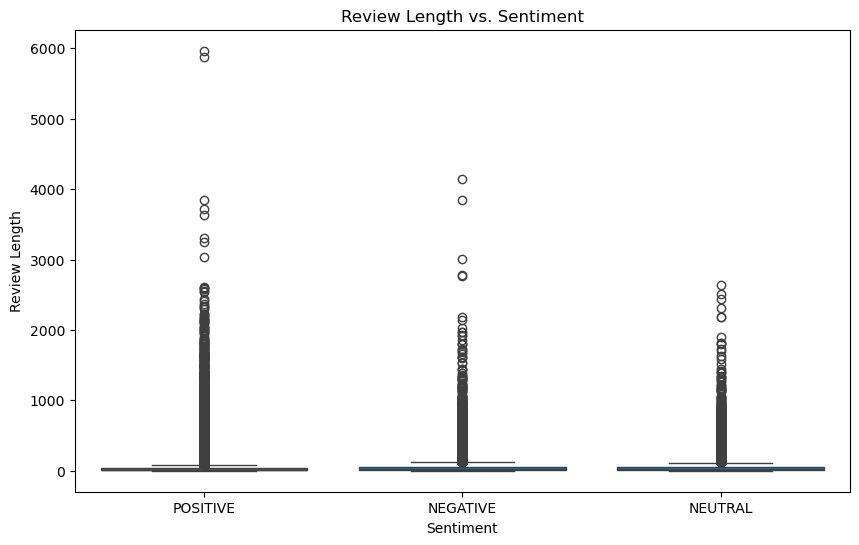

In [17]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='reviewText_length_words', data=data)
plt.title('Review Length vs. Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.show()

In [18]:
Q1 = data['reviewText_length_words'].quantile(0.25)
Q3 = data['reviewText_length_words'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data['reviewText_length_words'][(data['reviewText_length_words'] < lower_bound) | (data['reviewText_length_words'] > upper_bound)]
print(f"Number of outliers in review length: {len(outliers)}")

Number of outliers in review length: 140335


In [19]:
# Remove outliers
filtered_data = data[(data['reviewText_length_words'] >= lower_bound) & 
                     (data['reviewText_length_words'] <= upper_bound)]

print(f"Filtered data shape: {filtered_data.shape}")

Filtered data shape: (1494170, 14)


In [20]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1494170 entries, 0 to 1758332
Data columns (total 14 columns):
 #   Column                   Non-Null Count    Dtype 
---  ------                   --------------    ----- 
 0   overall                  1494170 non-null  int64 
 1   verified                 1494170 non-null  bool  
 2   reviewTime               1494170 non-null  object
 3   reviewerID               1494170 non-null  object
 4   asin                     1494170 non-null  object
 5   reviewerName             1494083 non-null  object
 6   reviewText               1494170 non-null  object
 7   summary                  1494170 non-null  object
 8   unixReviewTime           1494170 non-null  int64 
 9   vote                     134928 non-null   object
 10  style                    602916 non-null   object
 11  image                    20334 non-null    object
 12  reviewText_length_words  1494170 non-null  int64 
 13  label                    1494170 non-null  object
dtypes: bool

In [21]:
from sklearn.model_selection import train_test_split

sampled_df, _ = train_test_split(filtered_data,
                                 train_size=2000,
                                 stratify=filtered_data['label'],
                                 random_state=42)

In [22]:
sampled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 678373 to 1287455
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   overall                  2000 non-null   int64 
 1   verified                 2000 non-null   bool  
 2   reviewTime               2000 non-null   object
 3   reviewerID               2000 non-null   object
 4   asin                     2000 non-null   object
 5   reviewerName             2000 non-null   object
 6   reviewText               2000 non-null   object
 7   summary                  2000 non-null   object
 8   unixReviewTime           2000 non-null   int64 
 9   vote                     189 non-null    object
 10  style                    801 non-null    object
 11  image                    28 non-null     object
 12  reviewText_length_words  2000 non-null   int64 
 13  label                    2000 non-null   object
dtypes: bool(1), int64(3), object(10)
memo

In [23]:
sampled_df.head(5)

,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image,reviewText_length_words,label
678373,5,True,"06 5, 2014",A3H1T313YSK2U0,B00AZBIZTW,maria abreu,This is a great vacuum! I have gone through a few so I know what I'm talking about. It really is a one pass deal and emptying the canister is easier than my old ones. LOVE IT!,GREAT PRODUCT,1401926400,NaN,"{'Color:': ' Purple', 'Style Name:': ' Vacuum Only'}",NaN,37,POSITIVE
1272779,3,True,"11 22, 2014",A24FAUV92Z4NQ2,B0018MKX5Q,Roaster,"The clamp is nice and strong, but the one I got was made by hand, like with a piece of stock and a band saw. The dimensions are approximate, the sides are not square, and the rods joined by this clamp are not perpendicular. It's not for precision 90 alignment.",Perpendiculous screw clamp,1416614400,NaN,NaN,NaN,50,NEUTRAL
705849,5,True,"10 9, 2016",A13QDUSC20Z4E3,B00C351GBC,Andria,"For now we are vacuuming a lot more because of how easy this is to use. We haven't run the battery down all the way while using it. Great suction, picks up pet hair great.",Love to vacuum,1475971200,NaN,{'Color:': ' White'},NaN,35,POSITIVE
1431408,3,True,"12 19, 2016",A1PWHZ9C7U3AGF,B00AFCEJX2,Matthew M.,"The buttons work as expected. Packaging was bad. 2 arrived with bent pins, and one of the colored button caps arrived broken. I only needed 1 button, so it wasn't an issue, but should not have happened.",good buttons,1482105600,NaN,NaN,NaN,37,NEUTRAL
524565,5,True,"02 18, 2015",A5A4RGSDKK124,B005W0UWCY,t.allman,Easy to install. These lifted up my 500b maple workbench with ease. I can now push it around with one hand. I looked all over the internet for better pricing but they were all about the same cost. Heavy duty!!,Easy to install. Worked great.,1424217600,NaN,NaN,NaN,40,POSITIVE


In [24]:
sampled_df.to_csv("sampled_reviews.csv", index=False)